# Section 4：Steering 与 prompt 的 attention 误差

这里直接在 notebook 中定义并绘制所有图。修改下面的参数或 `combined_figure` 即可重画，无需改动其他绘图脚本。每层一张双面板图，另附第 **3、9、18、27、34 层的平均图**。

- 左侧固定追加 prompt 长度 $m=4$：蓝色为 input-only steering，橙色为 4 个 input + generated positions。实线是 measured error，虚线是理论上界；y 轴为对数刻度。
- 右侧固定 single-token steering：紫色展示追加 prompt 长度与 measured error；y 轴保持线性。
- 误差是未经归一化的 $\|o_{\mathrm{steer}}-o_{\mathrm{prompt}}\|_2$。阴影是输入之间的 mean ± sample std。左侧使用相同的 95 条长输入，右侧使用全部 400 条；五层平均版先在每条输入内平均 10 个 head 的标量值，再跨输入统计。
- 对数轴无法展示非正数，左侧阴影仅在显示时裁剪到正数轴下限；原始 mean/std 不变。391/400 条轨迹在第 128 步前出现 EOS，这些图是固定表示下的 attention 诊断。

选择项目 `.venv/bin/python` 内核；首次运行可执行 `uv sync --group dev`。运行最后两个 cell 后，**六张 SVG 图会直接显示在 notebook 中**，同时先保存六张 PDF 到 `figs/`。不生成 PNG，也不重新运行模型。

右侧均值 ± 标准差的下缘可能小于零；这只是对称阴影的计算结果，实际 L₂ 误差始终非负。右侧阴影仅在展示时裁到 0，原始统计值保留。

In [1]:
from pathlib import Path
import io
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "results/section4_long_summary.json").exists())
summary = json.loads((ROOT / "results/section4_long_summary.json").read_text())
stats = summary["comparison"] + summary["layer_mean_comparison"]

## 绘图参数

直接修改颜色、字号、层列表或 `combined_figure` 中的布局。横轴以 log₂ 间隔显示明确的 token 数；左侧 y 轴为 log₁₀，右侧 y 轴为线性。

In [2]:
LAYERS = [3, 9, 18, 27, 34]  # one-based layer numbers
LENGTHS = [1, 2, 4, 8, 16, 32, 64, 128]
COLORS = {"input": "#2673B8", "mixed": "#D97721", "prompt": "#7B4FA3"}
STYLE = {
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10, "legend.fontsize": 8,
    "pdf.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.linewidth": .7,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "figure.facecolor": "white", "savefig.facecolor": "white",
}
FIGSIZE = (11.2, 4.5)

In [3]:
def draw_line(ax, rows, field, x_position, label, color, log_floor=None, band_floor=None):
    rows = sorted(rows, key=x_position)
    x = [x_position(row) for row in rows]
    mean = np.array([row[field]["mean"] for row in rows])
    std = np.array([row[field]["std"] for row in rows])
    bound = field == "bound"
    visible_mean = mean if log_floor is None else np.ma.masked_less_equal(mean, 0)
    floor = log_floor if log_floor is not None else band_floor
    lower = mean - std if floor is None else np.maximum(mean - std, floor)
    upper = mean + std if log_floor is None else np.maximum(mean + std, log_floor)
    ax.plot(x, visible_mean, linestyle="--" if bound else "-",
            marker="s" if bound else "o", label=label, color=color,
            linewidth=1.7, markersize=4,
            markerfacecolor="white" if bound else color, zorder=3)
    ax.fill_between(x, lower, upper, color=color, alpha=.07 if bound else .14,
                    linewidth=0, zorder=1)


def format_x_axis(ax, xlabel):
    ax.set_xscale("log", base=2)
    ax.set_xticks(LENGTHS, labels=[str(x) for x in LENGTHS])
    ax.set_xlabel(xlabel, labelpad=8)
    ax.grid(axis="y", color="#E6E8EB", linewidth=.65)
    ax.set_axisbelow(True)
    ax.margins(x=.04)
    ax.tick_params(length=3, width=.6)


def figure_name(layer):
    return ("section4_layer_mean_combined.pdf" if layer == -1
            else f"section4_layer{layer + 1:02d}_combined.pdf")


def combined_figure(layer):
    """Build both panels from the tracked summary; -1 selects the five-layer mean."""
    steering = [r for r in stats if r["layer"] == layer and r["figure"] == "steering"]
    prompt = [r for r in stats if r["layer"] == layer and r["figure"] == "prompt"]
    title = "Five-layer mean" if layer == -1 else f"Layer {layer + 1}"
    with plt.rc_context(STYLE):
        fig, (left, right) = plt.subplots(1, 2, figsize=FIGSIZE,
                                        gridspec_kw={"width_ratios": [1.25, 1]})
        moments = [r[field] for r in steering for field in ("error", "bound")]
        positive = [v for row in moments
                    for v in (row["mean"], row["mean"] - row["std"]) if v > 0]
        floor = min(positive) / 1.8
        ceiling = max(row["mean"] + row["std"] for row in moments)
        left.set_yscale('log')
        left.set_ylim(floor, ceiling * (ceiling / floor) ** .34)
        configurations = [
            ([r for r in steering if r["g"] == 0], COLORS["input"], "input only"),
            ([r for r in steering if r["g"] or r["k"] == 4],
             COLORS["mixed"], "4 input + generated"),
        ]
        for rows, color, name in configurations:
            for field, kind in (("error", "Measured"), ("bound", "Bound")):
                draw_line(left, rows, field, lambda r: r["k"] + r["g"],
                          f"{kind} · {name}", color, log_floor=floor)
        format_x_axis(left, "Steered positions")
        left.set_ylabel("Raw L₂ error / bound (log scale)", labelpad=8)
        left.set_title(f'(a) Fixed prompt length m = 4  ·  n = {steering[0]["error"]["n"]}',
                       loc="left", pad=12)
        left.legend(loc="upper left", bbox_to_anchor=(0, 1.01), frameon=False,
                    handlelength=2.6, labelspacing=.45, borderaxespad=.4)

        draw_line(right, prompt, "error", lambda r: r["m"],
                  "Measured · single-token steering", COLORS["prompt"], band_floor=0)
        format_x_axis(right, "Appended prompt tokens")
        right.set_ylabel("Raw error", labelpad=8)
        right.set_title(f'(b) Single-token steering  ·  n = {prompt[0]["error"]["n"]}',
                        loc="left", pad=12)
        right.legend(loc="upper left", frameon=False, handlelength=2.6)
        low, high = right.get_ylim()
        right.set_ylim(0, high + .13 * (high - low))
        # fig.suptitle(f"Qwen3-4B  /  {title}", x=.085, ha="left", y=.99,
                     # fontsize=14, fontweight="bold")
        # fig.text(.085, .015,
        #          "Mean ± std · raw L₂ differences · left: log scale; bands clipped at positive axis floor",
        #          fontsize=9, color="#666666")
        fig.subplots_adjust(left=.085, right=.985, bottom=.18, top=.80, wspace=.32)
    return fig


def draw_layer(layer):
    """Export PDF, then show an SVG preview directly below this notebook cell."""
    fig = combined_figure(layer)
    path = ROOT / "figs" / figure_name(layer)
    fig.savefig(path, bbox_inches="tight")  # PDF first; never write PNG.
    message = f"Saved {path.relative_to(ROOT)}"
    print(message, flush=True)
    with (ROOT / "logs/section4_notebook.log").open("a") as log:
        print(message, file=log, flush=True)
    preview = io.StringIO()
    fig.savefig(preview, format="svg", bbox_inches="tight")
    plt.close(fig)
    display(SVG(preview.getvalue()))

## 五层平均

五层等权；因使用未归一化的 L₂ 差值，数值较大的层对均值影响更大。

Saved figs/section4_layer_mean_combined.pdf


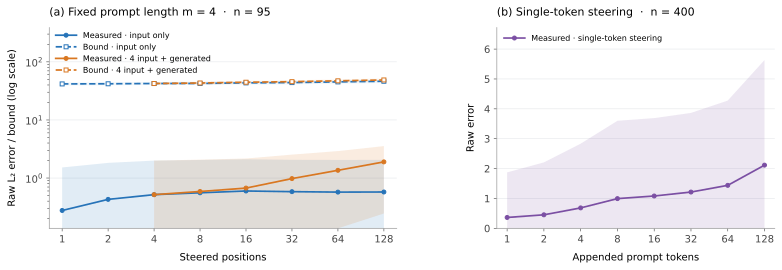

In [4]:
draw_layer(-1)

## 分层图

Saved figs/section4_layer03_combined.pdf


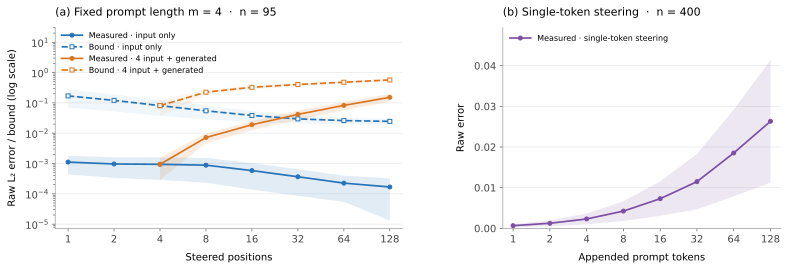

Saved figs/section4_layer09_combined.pdf


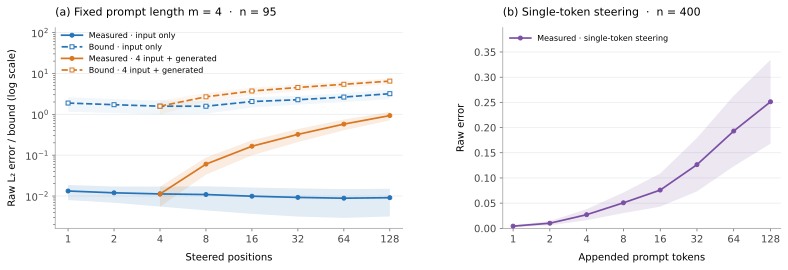

Saved figs/section4_layer18_combined.pdf


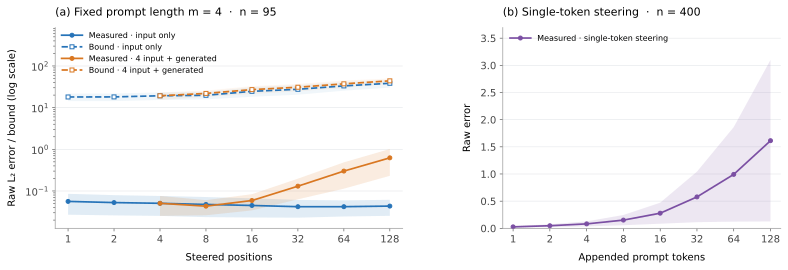

Saved figs/section4_layer27_combined.pdf


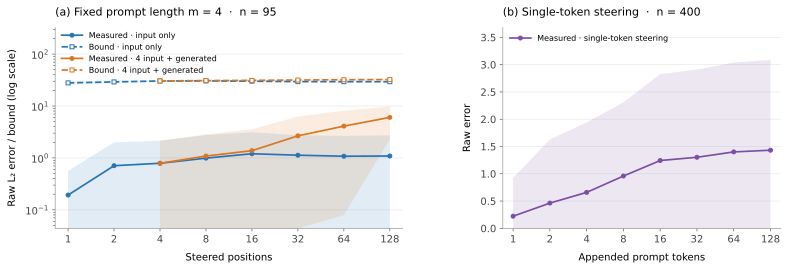

Saved figs/section4_layer34_combined.pdf


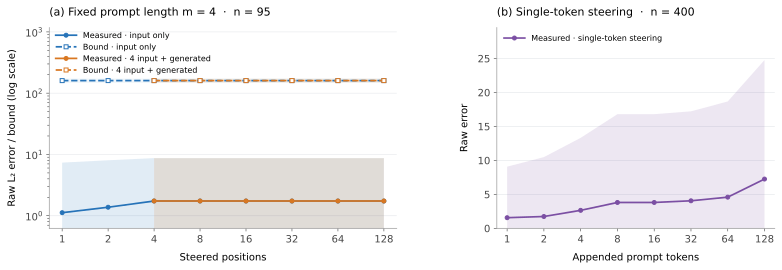

In [5]:
for layer in LAYERS:
    draw_layer(layer - 1)